In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df=sns.load_dataset("tips")
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


C:\Users\Pc\AppData\Local\Temp\ipykernel_7064\3779275581.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_bill=df.groupby("day")["total_bill"].mean()


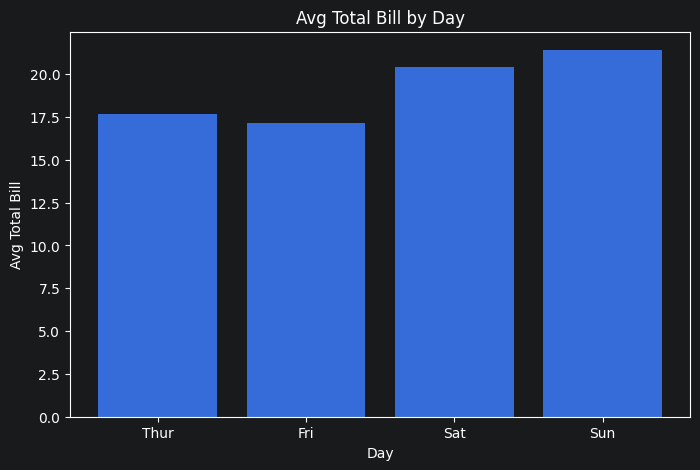

In [3]:
avg_bill=df.groupby("day")["total_bill"].mean()

plt.figure(figsize = (8,5))
plt.bar(avg_bill.index,avg_bill.values)

plt.xlabel("Day")
plt.ylabel("Avg Total Bill")
plt.title("Avg Total Bill by Day")

plt.show()

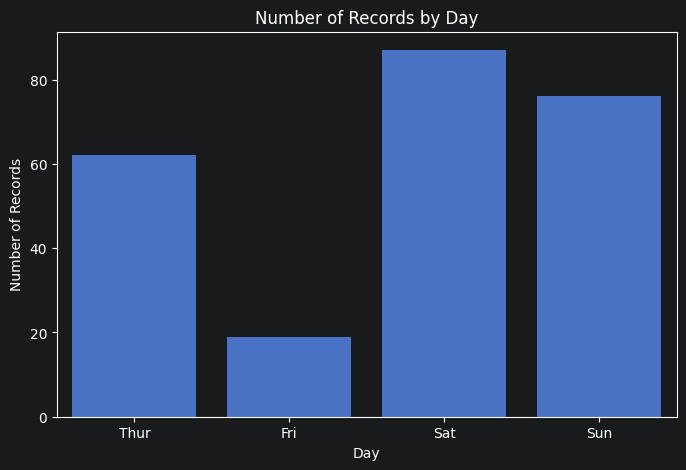

In [5]:
plt.figure(figsize = (8,5))
sns.countplot(data=df, x="day")

plt.xlabel("Day")
plt.ylabel("Number of Records")
plt.title("Number of Records by Day")
plt.show()

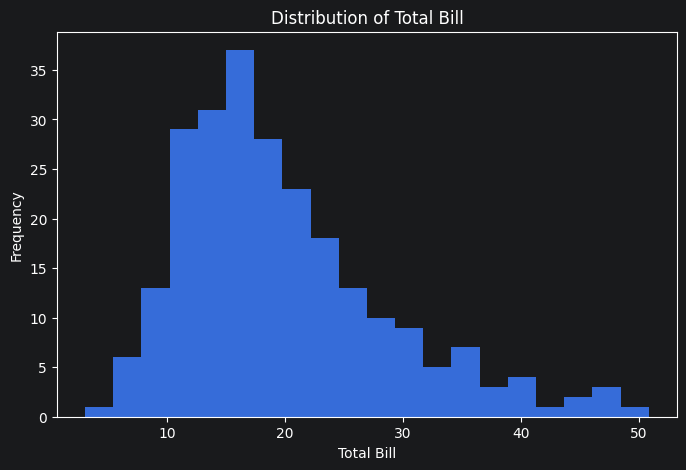

In [8]:
plt.figure(figsize = (8,5))

plt.hist(df['total_bill'], bins = 20)

plt.xlabel("Total Bill")
plt.ylabel("Frequency")
plt.title("Distribution of Total Bill")

plt.show()

#is right-skewed as most bills are smaller

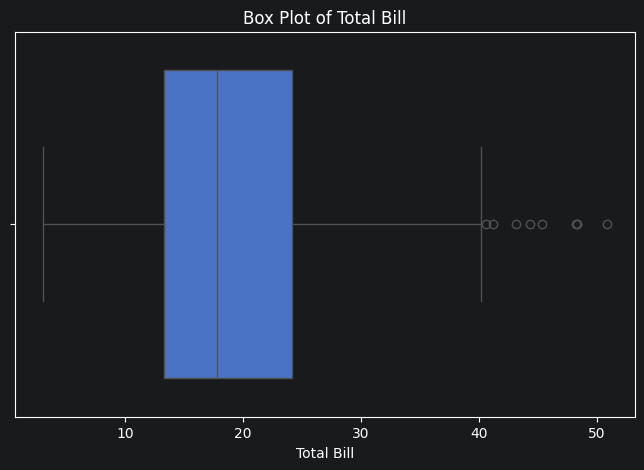

In [9]:
plt.figure(figsize = (8,5))

sns.boxplot(x=df['total_bill'])

plt.xlabel("Total Bill")
plt.title("Box Plot of Total Bill")
plt.show()


In [18]:
q1=df["total_bill"].quantile(0.25)
q3=df["total_bill"].quantile(0.75)

iqr=q3-q1

lower=q1-1.5*iqr
upper=q3+1.5*iqr

outliers=df[(df["total_bill"]<lower) |(df["total_bill"]>upper)]

print("Q1:",q1)
print("Q3:",q3)
print("IQR:",iqr)
print("Lower:",lower)
print("Upper:",upper)
print("Outliers:", len(outliers))

Q1: 13.3475
Q3: 24.127499999999998
IQR: 10.779999999999998
Lower: -2.8224999999999945
Upper: 40.29749999999999
Outliers: 9


In [19]:
from scipy import stats

df["zscore"]=stats.zscore(df["total_bill"])
outliers=df[df["zscore"].abs()>3]

print("Number of outliers:",len(outliers))

Number of outliers: 4


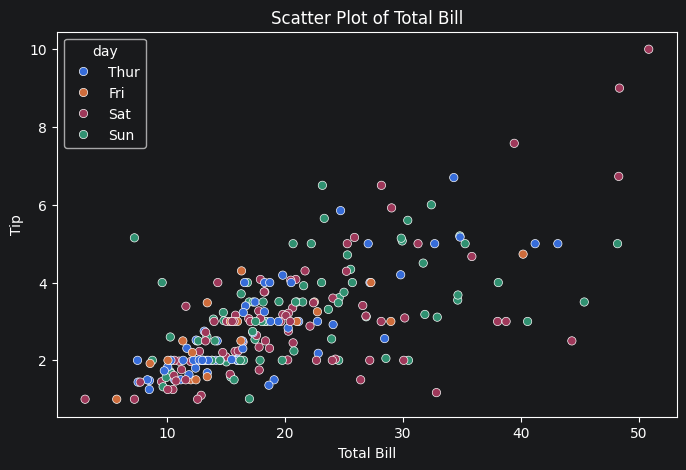

In [21]:
plt.figure(figsize = (8,5))
sns.scatterplot(data=df, x="total_bill", y="tip", hue="day")

plt.xlabel("Total Bill")
plt.ylabel("Tip")
plt.title("Scatter Plot of Total Bill")
plt.show()

day
Thur    17.682742
Fri     17.151579
Sat     20.441379
Sun     21.410000
Name: total_bill, dtype: float64


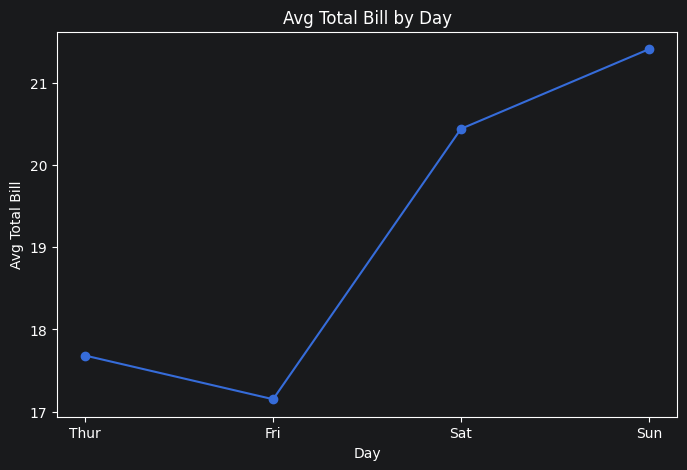

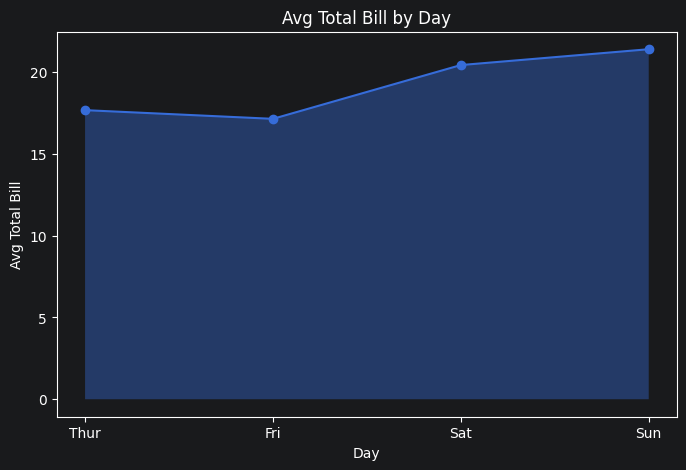

In [27]:
day_order=["Thur","Fri","Sat","Sun"]
avg_bil_day=df.groupby("day", observed=False)["total_bill"].mean()
avg_bill_day=avg_bil_day.reindex(day_order)

print(avg_bil_day)

plt.figure(figsize=(8,5))
plt.plot(avg_bil_day.index,avg_bil_day.values,marker="o")
plt.xlabel("Day")
plt.ylabel("Avg Total Bill")
plt.title("Avg Total Bill by Day")
plt.show()

plt.figure(figsize=(8,5))
plt.fill_between(range(len(avg_bill_day)), avg_bil_day.values, alpha=0.4)

plt.plot(range(len(avg_bill_day)), avg_bil_day.values,marker="o")

plt.xticks(range(len(avg_bill_day)), avg_bill_day.index)
plt.xlabel("Day")
plt.ylabel("Avg Total Bill")
plt.title("Avg Total Bill by Day")
plt.show()

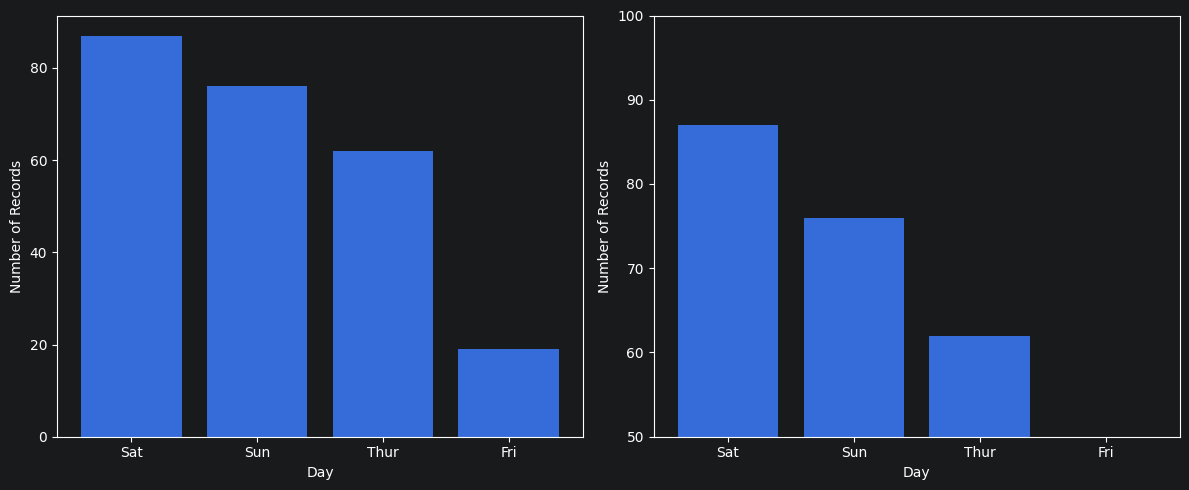

In [32]:
day_counts = df["day"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(day_counts.index,day_counts.values)
axes[0].set_xlabel("Day")
axes[0].set_ylabel("Number of Records")

axes[1].bar(day_counts.index,day_counts.values)
axes[1].set_xlabel("Day")
axes[1].set_ylabel("Number of Records")

axes[1].set_ylim(50, 100)
plt.tight_layout()
plt.show()